# 01a · The gentlest models — linear & logistic regression

*Before trees and neural nets: the two models every course starts with.*

> ⏱ **Runtime:** ~10 s on a laptop CPU (no GPU) · 🎓 **Level:** beginner · 📊 **Data:** Al–Cu map

### 🎯 What you'll learn
1. **linear regression**: fit a straight line to predict one number from another,
2. how to read a **slope**, **intercept** and **R²**,
3. **logistic regression**: the same idea bent into a **classifier** (predict a phase),
4. what a **decision boundary** is and how a model turns features into a probability.

### 🧭 What you need to know first
- Notebook **01** (features, standardisation).
- R² is introduced here and revisited in notebook 12.

> 🧭 **Where this fits.** These are the simplest supervised models — a great first rung. Linear
> regression predicts a **number**; logistic regression predicts a **class**. Everything later
> (trees, forests, CNNs) is a more flexible answer to these same two questions.

### Step 0 — set-up

Run the cell below first. In Jupyter you run a cell by clicking it and pressing **Shift + Enter**.

> 🟢 **On Google Colab** this cell also clones the repo and installs a few extra packages — it takes about a minute the first time. On your own machine (after `pip install -r requirements.txt`) it's instant.

> ✅ **You should see:** a line like `helpers loaded from: .../mecanano_ml/__init__.py` — that means the helper package loaded correctly.

In [1]:
# --- Setup cell — run me first! ---------------------------------------------
# It makes the helper package `mecanano_ml` importable and sets a clean plot
# style. You do not need to understand every line here; just run it.
# On Google Colab it also clones the repo and installs the few extra packages
# Colab doesn't ship (takes ~1 min, once per session).
import os, sys, subprocess

def _find_src():
    # Look for the repo's src/ folder in the usual places (local clone / Colab).
    for p in ("../src", "src", "mecanano-ml-nanomechanics/src"):
        if os.path.isdir(p):
            return p
    return None

if "google.colab" in sys.modules:             # running on Colab -> set everything up
    # packages Colab does not preinstall (torch/sklearn/etc. are already there):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "hdbscan", "umap-learn", "pyts", "shap", "imbalanced-learn"],
                   check=False)

if _find_src() is None:                       # bare session (e.g. Colab): fetch the repo
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/edrossi93/mecanano-ml-nanomechanics.git"],
                   check=False)

sys.path.insert(0, os.path.abspath(_find_src() or "mecanano-ml-nanomechanics/src"))

import numpy as np                 # arrays and maths
import pandas as pd                # tables (each row = one indent)
import matplotlib.pyplot as plt    # plotting
import mecanano_ml as mm           # our tiny helper package: loaders + plotting
mm.set_style()                     # consistent, publication-like figures
# Confirm the helpers loaded (just the tail of the path, not your machine's folders).
_pkg = os.path.basename(os.path.dirname(mm.__file__))
print("helpers loaded from: .../" + _pkg + "/" + os.path.basename(mm.__file__))

helpers loaded from: .../mecanano_ml/__init__.py


In [2]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score, accuracy_score
rng = np.random.default_rng(0)

## 1 · Linear regression: predict modulus from hardness

Hardness `H` and modulus `E` are physically related, so knowing one should help predict the other.
The simplest model draws the **best straight line** `E ≈ slope·H + intercept` through the cloud.

> 🧠 **linear regression** — fit a straight line (or flat plane) that minimises the squared distance to the data. The output is a number.

> 🧠 **slope & intercept** — the line's tilt and where it crosses the axis: `prediction = slope · H + intercept`.

> ✅ **When you run the next cell, you should see:** the fitted slope, intercept and an **R²** (fraction of E explained by H), plus a scatter with the red best-fit line through it.

slope = 7.00 GPa/GPa, intercept = 60.5 GPa
R^2 = 0.710   (1 = perfect, 0 = no better than the mean)


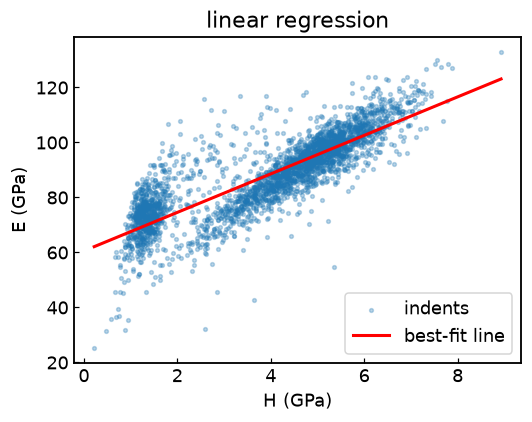

In [3]:
df = mm.load_map("alcu_2um")
samp = df.sample(3000, random_state=0)            # subsample just for a clean plot
H = samp[["H"]].values                            # predictor (must be 2-D for sklearn)
E = samp["E"].values                              # target (what we predict)

lin = LinearRegression().fit(H, E)
E_pred = lin.predict(H)
print(f"slope = {lin.coef_[0]:.2f} GPa/GPa, intercept = {lin.intercept_:.1f} GPa")
print(f"R^2 = {r2_score(E, E_pred):.3f}   (1 = perfect, 0 = no better than the mean)")

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(H, E, s=6, alpha=.3, label="indents")
order = np.argsort(H.ravel())
ax.plot(H.ravel()[order], E_pred[order], "r-", lw=2, label="best-fit line")
ax.set_xlabel("H (GPa)"); ax.set_ylabel("E (GPa)"); ax.legend(); ax.set_title("linear regression")
fig.tight_layout()

*🖼 **Figure.** The red line is the least-squares fit. R² tells you how tight the cloud hugs it — high R² = H predicts E well; the two phases show up as two blobs along the line.*

## 2 · Logistic regression: predict the phase

Now a **classification** task: which phase is an indent? We first make two-phase labels by clustering
`H, E` (as in notebook 02), then let **logistic regression** find the straight line that best
separates them. Despite the name, it is a **classifier**.

> 🧠 **logistic regression** — a linear classifier: it combines the features into a score, then squashes the score to a probability between 0 and 1 with an S-shaped (sigmoid) curve. Above 0.5 → one class, below → the other.

> 🧠 **decision boundary** — the line (or surface) where the model switches its prediction from one class to the other. For logistic regression it is straight.

> ✅ **When you run the next cell, you should see:** a printed accuracy (~0.9+) and a scatter of the two phases with the straight **decision boundary** drawn through them.

training accuracy: 0.998


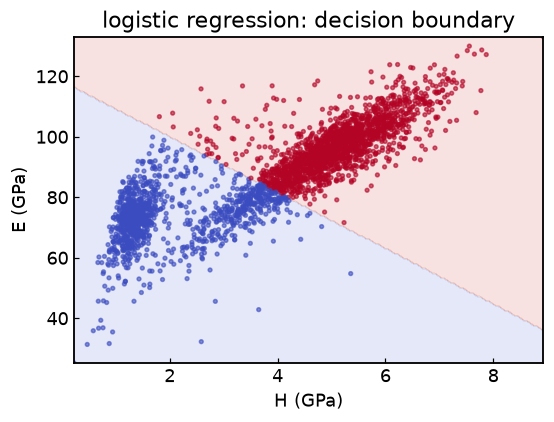

In [4]:
X = samp[["H", "E"]].values
# Labels from clustering (unsupervised), named so 1 = harder phase.
lab = KMeans(2, n_init=10, random_state=0).fit_predict(StandardScaler().fit_transform(X))
y = (lab == df.loc[samp.index].groupby(lab)["H"].median().idxmax()).astype(int)

# Standardise, then fit logistic regression.
sc = StandardScaler().fit(X); Xs = sc.transform(X)
clf = LogisticRegression().fit(Xs, y)
print("training accuracy:", round(accuracy_score(y, clf.predict(Xs)), 3))

# Draw the decision boundary on a grid over H–E space.
hh, ee = np.meshgrid(np.linspace(X[:, 0].min(), X[:, 0].max(), 200),
                     np.linspace(X[:, 1].min(), X[:, 1].max(), 200))
grid = sc.transform(np.c_[hh.ravel(), ee.ravel()])
zz = clf.predict(grid).reshape(hh.shape)

fig, ax = plt.subplots(figsize=(5.2, 4))
ax.contourf(hh, ee, zz, alpha=.15, cmap="coolwarm")           # coloured regions
ax.scatter(X[:, 0], X[:, 1], c=y, s=6, cmap="coolwarm", alpha=.6)
ax.set_xlabel("H (GPa)"); ax.set_ylabel("E (GPa)"); ax.set_title("logistic regression: decision boundary")
fig.tight_layout()

*🖼 **Figure.** The shaded regions are the model's two 'territories'; the line between them is the decision boundary. Logistic regression can only draw a straight one — enough here because the phases separate cleanly.*

## 3 · It also gives probabilities

Logistic regression doesn't just say 'phase 1' — it reports **how confident** it is (like the GMM in
notebook 02). Points near the boundary get probabilities near 0.5.

> ✅ **When you run the next cell, you should see:** a scatter coloured by the predicted probability of the hard phase — a smooth gradient from 0 to 1 across the boundary.

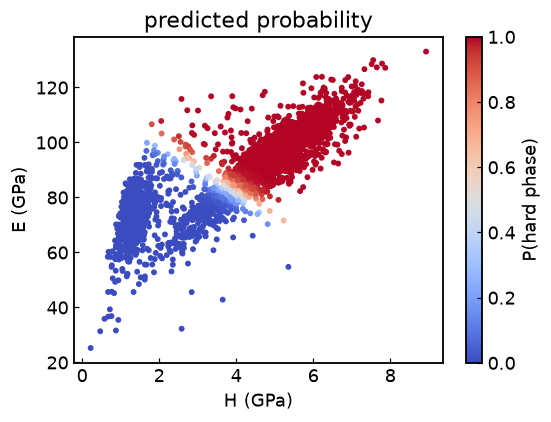

In [5]:
proba = clf.predict_proba(Xs)[:, 1]               # probability of the hard phase
fig, ax = plt.subplots(figsize=(5.2, 4))
s = ax.scatter(X[:, 0], X[:, 1], c=proba, s=8, cmap="coolwarm")
plt.colorbar(s, label="P(hard phase)")
ax.set_xlabel("H (GPa)"); ax.set_ylabel("E (GPa)"); ax.set_title("predicted probability")
fig.tight_layout()

*🖼 **Figure.** The colour is the model's confidence. The fuzzy band at ~0.5 marks indents the model considers borderline — exactly the phase boundary.*

### ✅ Self-check
A quick sanity test that the numbers above came out sensible. If you edit the notebook and a result drifts badly, the cell below will stop with an `AssertionError` — a helpful early warning, not a bug.

In [6]:
# Each line fails loudly if a key result drifts out of a sensible range.
# (These also run in CI, so a broken result fails the build.)
assert r2_score(E, E_pred) > 0.5, "H should predict E moderately well"
assert accuracy_score(y, clf.predict(Xs)) > 0.9, "logistic regression should separate the phases"
print("self-check passed ✓ — line fit and classifier work")

self-check passed ✓ — line fit and classifier work


## ✅ Recap
- **Linear regression** fits a line to predict a number; judge it with **R²**.
- **Logistic regression** is a linear **classifier**: it draws a straight **decision boundary** and reports a **probability**.
- These are the baselines to beat — reach for trees/forests (notebook 03) when a straight line isn't enough.

## 🔧 Try it yourself
Small changes teach the most. Try these (re-run the cell after each):
1. Regress `H` from `E` instead of `E` from `H`. Is the R² the same? (It is — R² is symmetric here.)
2. Give logistic regression only `H` (drop `E`). Does the boundary become a vertical line? Does accuracy drop?
3. Add `HE` as a third feature to the classifier. Does training accuracy improve?

## 🩹 Common errors & fixes
- **`ValueError: Expected 2D array`** → a single feature must be shaped `df[["H"]]` (note the double brackets), not `df["H"]`.
- **Boundary looks flipped** → cluster ids are arbitrary; we name the hard phase by median H, so the colours stay consistent.
- **Accuracy is suspiciously perfect** → remember the labels came from clustering the same features; notebook 03a shows how to evaluate honestly.

---
**Next:** **`02a_knn_classifier.ipynb`** — classify by nearest neighbours, a model with no straight-line assumption at all.